# Subscription Cohort Analysis
**Objective:** Clean and prepare subscription data for cohort churn analysis in Power BI.

**Dataset:** 3,069 customer subscription records with fields for subscription cost, dates, payment status, and churn indicators.

**Workflow:**
1. Load data
2. Inspect & check for nulls
3. Convert date columns
4. Engineer derived columns
5. Exploratory Data Analysis (EDA)
6. Export cleaned data

## 1. Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Data
- `df1` — Data dictionary (field descriptions)
- `df2` — Main subscription dataset

In [10]:
df1 = pd.read_csv('Subscription Cohort Analysis Data Dictionary.csv')
df1.head()
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Field        6 non-null      object
 1   Description  6 non-null      object
dtypes: object(2)
memory usage: 228.0+ bytes


In [11]:
df2 = pd.read_csv("Subscription Cohort Analysis Data.csv")
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3069 entries, 0 to 3068
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   customer_id            3069 non-null   int64 
 1   created_date           3069 non-null   object
 2   canceled_date          2004 non-null   object
 3   subscription_cost      3069 non-null   int64 
 4   subscription_interval  3069 non-null   object
 5   was_subscription_paid  3069 non-null   object
dtypes: int64(2), object(4)
memory usage: 144.0+ KB


## 3. Inspect Nulls
Checking for missing values. The `canceled_date` column is expected to have nulls — these represent customers who are still active and have not cancelled.

In [12]:
print("df1 nulls:")
print(df1.isnull().sum())
print("\ndf2 nulls:")
print(df2.isnull().sum())

df1 nulls:
Field          0
Description    0
dtype: int64

df2 nulls:
customer_id                 0
created_date                0
canceled_date            1065
subscription_cost           0
subscription_interval       0
was_subscription_paid       0
dtype: int64


## 4. Convert Date Columns
Both `created_date` and `canceled_date` are stored as object (string) dtype. Converting to datetime enables date arithmetic for calculating subscription duration and cohort grouping.

In [13]:
df2['created_date'] = pd.to_datetime(df2['created_date'])
df2['canceled_date'] = pd.to_datetime(df2['canceled_date'])

# Verify conversion
df2[['created_date', 'canceled_date']].dtypes

created_date     datetime64[ns]
canceled_date    datetime64[ns]
dtype: object

## 5. Engineer Derived Columns
Creating four new columns to support analysis:
- `subscription_duration_days` — how long a customer stayed before cancelling (null for active customers)
- `is_churned` — boolean flag, True if customer has cancelled
- `status` — human-readable label: Active or Cancelled
- `cohort_month` — the month a customer first subscribed, used for cohort grouping

In [14]:
# Subscription duration in days (only populated for churned customers)
df2['subscription_duration_days'] = (
    df2['canceled_date'] - df2['created_date']
).dt.days

In [16]:
# Churn flag and status label
df2['is_churned'] = df2['canceled_date'].notna()
df2['status'] = df2['canceled_date'].apply(lambda x: 'Cancelled' if pd.notna(x) else 'Active')


In [15]:
# Cohort month — groups customers by their signup month for retention analysis
df2['cohort_month'] = df2['created_date'].dt.to_period('M')

In [17]:
# Verify final dataframe shape and dtypes
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3069 entries, 0 to 3068
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   customer_id                 3069 non-null   int64         
 1   created_date                3069 non-null   datetime64[ns]
 2   canceled_date               2004 non-null   datetime64[ns]
 3   subscription_cost           3069 non-null   int64         
 4   subscription_interval       3069 non-null   object        
 5   was_subscription_paid       3069 non-null   object        
 6   subscription_duration_days  2004 non-null   float64       
 7   cohort_month                3069 non-null   period[M]     
 8   is_churned                  3069 non-null   bool          
 9   status                      3069 non-null   object        
dtypes: bool(1), datetime64[ns](2), float64(1), int64(2), object(3), period[M](1)
memory usage: 218.9+ KB


In [18]:
# Preview first 5 rows
df2.head()

,customer_id,created_date,canceled_date,subscription_cost,subscription_interval,was_subscription_paid,subscription_duration_days,cohort_month,is_churned,status
0,154536156,2022-09-01,NaT,39,month,Yes,NaN,2022-09,False,Active
1,149713408,2022-09-01,2022-09-02,39,month,No,1.0,2022-09,True,Cancelled
2,153756284,2022-09-01,2022-09-02,39,month,No,1.0,2022-09,True,Cancelled
3,121253113,2022-09-01,2022-09-23,39,month,Yes,22.0,2022-09,True,Cancelled
4,154467210,2022-09-01,2023-06-29,39,month,Yes,301.0,2022-09,True,Cancelled


## 6. Exploratory Data Analysis (EDA)
Before exporting to Power BI, we explore the key distributions and patterns in the data.

### 6.1 Basic Statistical Summary
Summary statistics for all numerical columns.

In [19]:
df2.describe()

,customer_id,created_date,canceled_date,subscription_cost,subscription_duration_days
count,3.069000e+03,3069,2004,3069.0,2004.000000
mean,1.827553e+08,2023-03-16 14:20:59.824047104,2023-04-10 14:42:23.712574976,39.0,58.374251
min,1.113945e+08,2022-09-01 00:00:00,2022-09-02 00:00:00,39.0,0.000000
25%,1.559263e+08,2022-12-22 00:00:00,2023-02-02 00:00:00,39.0,22.000000
50%,1.841436e+08,2023-03-19 00:00:00,2023-04-17 00:00:00,39.0,38.000000
75%,2.142482e+08,2023-06-19 00:00:00,2023-06-28 00:00:00,39.0,83.000000
max,2.211896e+08,2023-09-08 00:00:00,2023-09-08 00:00:00,39.0,348.000000
std,3.007863e+07,NaN,NaN,0.0,56.906846


### 6.2 Customer Status Distribution
How many customers are active vs cancelled?

status
Cancelled    2004
Active       1065
Name: count, dtype: int64

Churn Rate: 65.30%


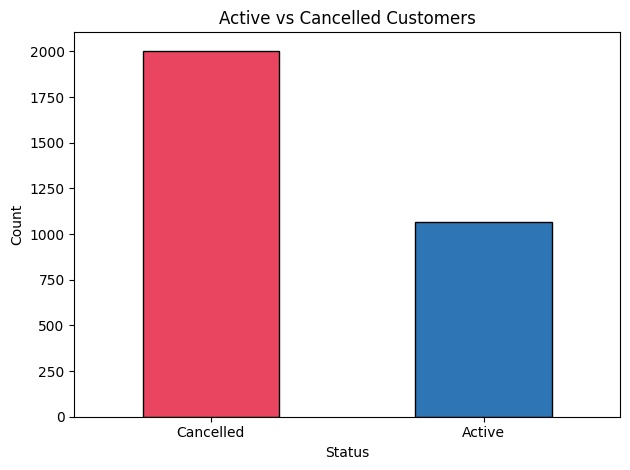

In [20]:
status_counts = df2['status'].value_counts()
print(status_counts)
print(f"\nChurn Rate: {status_counts['Cancelled'] / len(df2) * 100:.2f}%")

status_counts.plot(kind='bar', color=['#E94560', '#2E75B6'], edgecolor='black')
plt.title('Active vs Cancelled Customers')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 6.3 Payment Status Distribution
What proportion of subscriptions were paid vs unpaid?

was_subscription_paid
Yes    2936
No      133
Name: count, dtype: int64


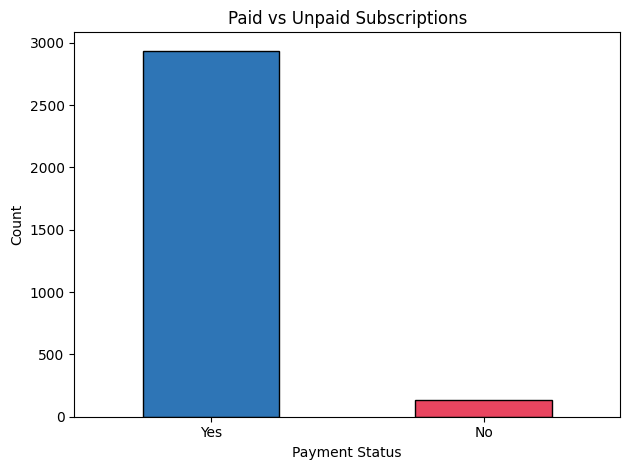

In [21]:
paid_counts = df2['was_subscription_paid'].value_counts()
print(paid_counts)

paid_counts.plot(kind='bar', color=['#2E75B6', '#E94560'], edgecolor='black')
plt.title('Paid vs Unpaid Subscriptions')
plt.xlabel('Payment Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 6.4 Subscription Duration Distribution
How long do customers stay before cancelling? This histogram shows the spread of subscription durations among churned customers only.

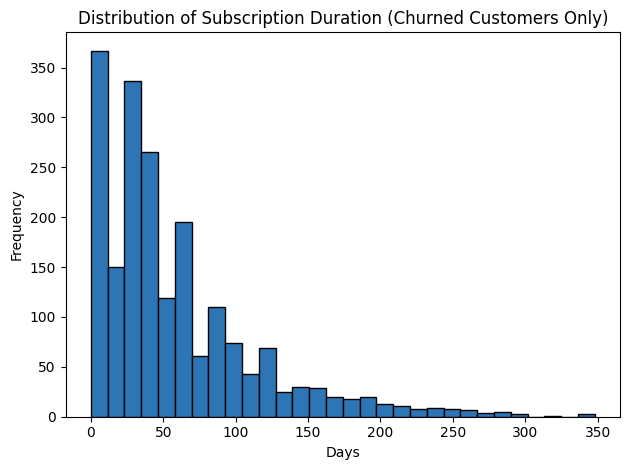

Average duration before churn: 58.4 days
Median duration before churn: 38.0 days


In [22]:
df2['subscription_duration_days'].dropna().plot(
    kind='hist', bins=30, color='#2E75B6', edgecolor='black'
)
plt.title('Distribution of Subscription Duration (Churned Customers Only)')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Average duration before churn: {df2['subscription_duration_days'].mean():.1f} days")
print(f"Median duration before churn: {df2['subscription_duration_days'].median():.1f} days")

### 6.5 Monthly Churn Trend
How many cancellations occurred each month? This helps identify any seasonal spikes or trends in churn over time.

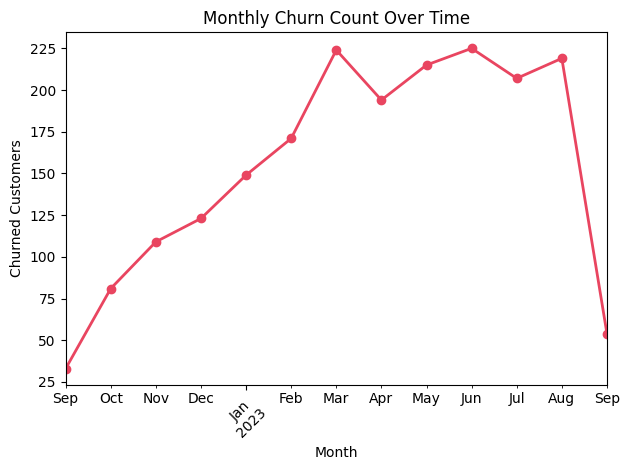

Peak churn month: 2023-06 with 225 cancellations


In [23]:
monthly_churn = (
    df2[df2['is_churned'] == True]
    .groupby(df2['canceled_date'].dt.to_period('M'))
    .size()
)

monthly_churn.plot(kind='line', color='#E94560', marker='o', linewidth=2)
plt.title('Monthly Churn Count Over Time')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Peak churn month: {monthly_churn.idxmax()} with {monthly_churn.max()} cancellations")

## 7. Export Cleaned Data
Converting `cohort_month` from Period dtype to string before export — Power BI cannot read the Period dtype directly from CSV. The cleaned file serves as the single source of truth for the Power BI dashboard.

In [24]:
# Convert period to string for CSV compatibility
df2['cohort_month'] = df2['cohort_month'].astype(str)

df2.to_csv('cleaned_subscriptions.csv', index=False)
print("Export complete: cleaned_subscriptions.csv")

Export complete: cleaned_subscriptions.csv
